# Audio ML Classifier: Classical DSP Feature Extraction & Machine Learning

This notebook demonstrates an end-to-end audio classification pipeline for spoken command recognition (Google Speech Commands dataset) using:
- **DSP Feature Extraction:** STFT magnitude spectrograms & Mel-Frequency Cepstral Coefficients (MFCC)
- **Feature Engineering:** Time-aggregated summary statistics (mean + standard deviation per MFCC)
- **Classical ML Classification:** Random Forest & Support Vector Machines (SVM)
- **Deep Learning Stretch:** PyTorch Multi-Layer Perceptron (MLP)
- **Evaluation:** Confusion matrix, per-class precision/recall/F1, and performance benchmarks.

In [1]:
import os
import sys
from pathlib import Path

# Ensure project root is on Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd

from src.preprocess import load_and_fix_length, normalize_audio
from src.features import extract_stft, extract_mfcc, mfcc_to_feature_vector
from src.data_loader import build_file_index, download_speech_commands_subset, DEFAULT_CLASSES

print("Environment initialized successfully!")
print("Target speech command classes:", DEFAULT_CLASSES)

Environment initialized successfully!
Target speech command classes: ['yes', 'no', 'stop', 'go', 'up']


## 1. Dataset Indexing & Class Distribution
We index the downloaded Google Speech Commands audio files across the 5 target classes (`yes`, `no`, `stop`, `go`, `up`).

In [2]:
df_index = build_file_index(data_dir="../data/raw", selected_classes=DEFAULT_CLASSES, samples_per_class=100)
print(f"Total clips indexed: {len(df_index)}")
display(df_index["label"].value_counts().to_frame("clip_count"))
df_index.head()

Total clips indexed: 500


,clip_count
label,
go,100
yes,100
no,100
up,100
stop,100


,filepath,label
0,C:\Projects\Audio_ML project\data\raw\go\a13e0...,go
1,C:\Projects\Audio_ML project\data\raw\yes\cb29...,yes
2,C:\Projects\Audio_ML project\data\raw\go\bd11c...,go
3,C:\Projects\Audio_ML project\data\raw\no\8a5ac...,no
4,C:\Projects\Audio_ML project\data\raw\no\14775...,no


## 2. Audio Loading & Preprocessing
Each clip is resampled to 16,000 Hz mono, trimmed of leading/trailing silence (at 20 dB threshold), and padded or truncated to exactly 1.0 second (16,000 samples).

In [3]:
sample_row = df_index.iloc[0]
filepath = sample_row["filepath"]
label = sample_row["label"]

y = load_and_fix_length(filepath, sr=16000, duration=1.0)
print(f"Loaded clip: {filepath}")
print(f"Class: {label} | Sample Rate: 16,000 Hz | Shape: {y.shape} | Duration: {len(y)/16000:.2f}s")

# Listen to sample audio
ipd.Audio(y, rate=16000)

Loaded clip: C:\Projects\Audio_ML project\data\raw\go\a13e0a74_nohash_0.wav
Class: go | Sample Rate: 16,000 Hz | Shape: (16000,) | Duration: 1.00s


## 3. DSP Visualizations (Waveform, STFT Spectrogram, MFCC)
Visualizing the acoustic properties of the spoken command across time and frequency representations.

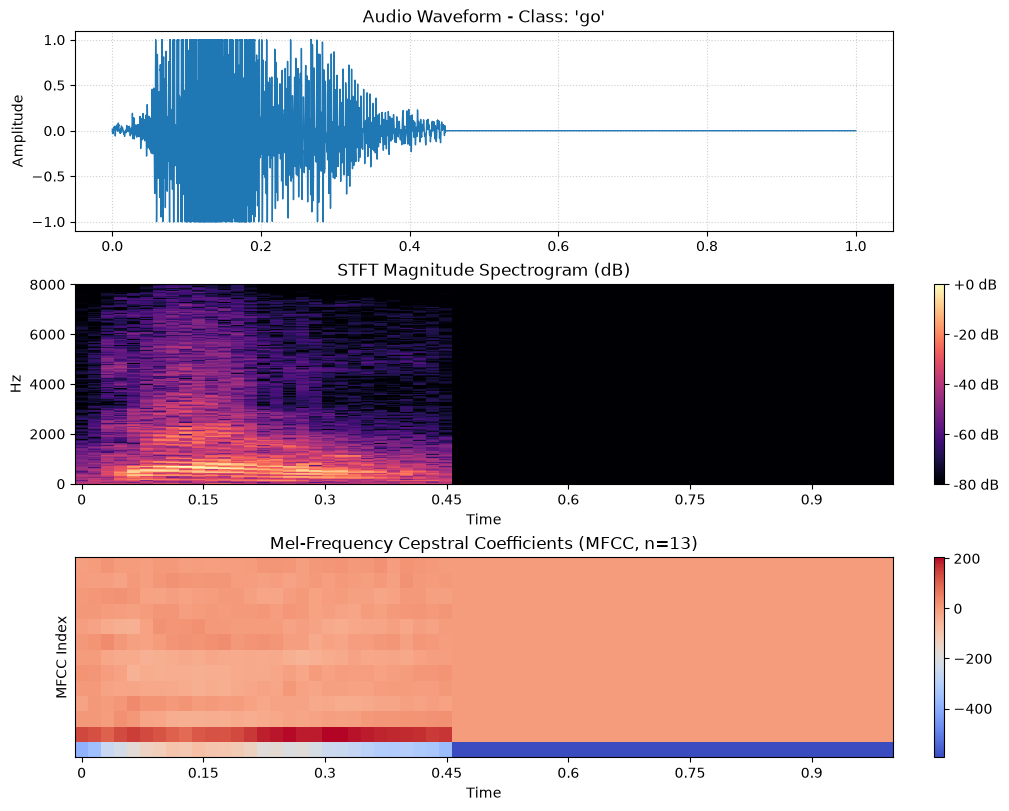

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)
time_axis = np.linspace(0, 1.0, len(y))

# 1. Waveform
axes[0].plot(time_axis, y, color="#1f77b4", lw=1.0)
axes[0].set_title(f"Audio Waveform - Class: '{label}'", fontsize=12)
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, linestyle=":", alpha=0.6)

# 2. STFT Spectrogram
D, S_db = extract_stft(y, n_fft=512, hop_length=256)
img1 = librosa.display.specshow(S_db, sr=16000, hop_length=256, x_axis="time", y_axis="hz", ax=axes[1], cmap="magma")
fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")
axes[1].set_title("STFT Magnitude Spectrogram (dB)", fontsize=12)

# 3. MFCC Heatmap
mfcc = extract_mfcc(y, sr=16000, n_mfcc=13, hop_length=256)
img2 = librosa.display.specshow(mfcc, sr=16000, hop_length=256, x_axis="time", ax=axes[2], cmap="coolwarm")
fig.colorbar(img2, ax=axes[2])
axes[2].set_title("Mel-Frequency Cepstral Coefficients (MFCC, n=13)", fontsize=12)
axes[2].set_ylabel("MFCC Index")

plt.show()

## 4. Feature Extraction: Time-Aggregated MFCC Statistics
We aggregate the 2D MFCC matrix across the time axis by computing the mean and standard deviation for each coefficient, producing a compact 26-dimensional feature vector per clip.

MFCC matrix shape: (13, 63) -> Aggregated feature vector shape: (26,)


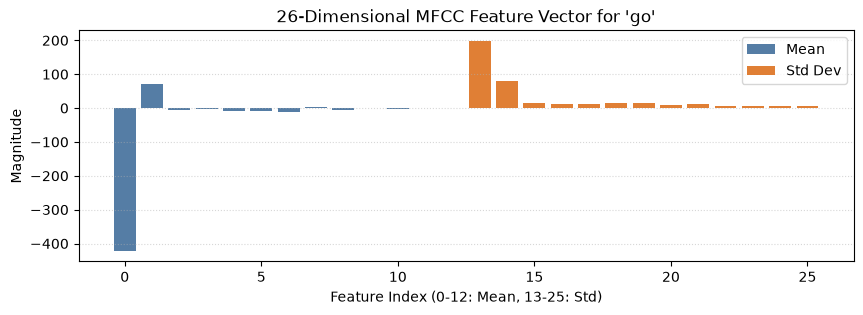

In [5]:
feat_vec = mfcc_to_feature_vector(mfcc)
print(f"MFCC matrix shape: {mfcc.shape} -> Aggregated feature vector shape: {feat_vec.shape}")

plt.figure(figsize=(10, 3))
plt.bar(range(13), feat_vec[:13], label="Mean", alpha=0.8, color="#2b5c8f")
plt.bar(range(13, 26), feat_vec[13:], label="Std Dev", alpha=0.8, color="#d95f02")
plt.xlabel("Feature Index (0-12: Mean, 13-25: Std)")
plt.ylabel("Magnitude")
plt.title(f"26-Dimensional MFCC Feature Vector for '{label}'")
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.show()

## 5. Model Training & Evaluation
We load the extracted features table `data/processed/features.csv`, split into train/test (80/20 stratified), and evaluate the trained Random Forest classifier.

=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

          go       0.46      0.60      0.52        20
          no       0.40      0.30      0.34        20
        stop       0.56      0.45      0.50        20
          up       0.62      0.75      0.68        20
         yes       0.74      0.70      0.72        20

    accuracy                           0.56       100
   macro avg       0.56      0.56      0.55       100
weighted avg       0.56      0.56      0.55       100



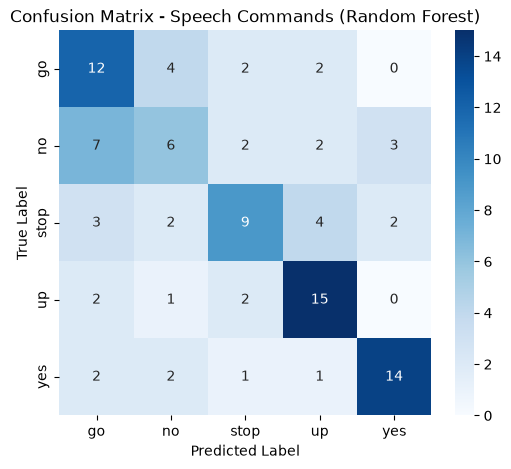

In [6]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix

# Load test split and models if already trained, or evaluate
test_data = np.load("../data/processed/test_split.npz", allow_pickle=True)
X_test = test_data["X_test"]
y_test = test_data["y_test"]

rf_clf = joblib.load("../models/rf_classifier.pkl")
le = joblib.load("../models/label_encoder.pkl")

y_pred = rf_clf.predict(X_test)
print("=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Speech Commands (Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()